### Loading the Breast Cancer Wisconsin Dataset

In this section, we will work with the Breast Cancer Wisconsin dataset, which contains 569 examples of malignant and benign tumor cells. The first two columns in the dataset store the unique ID numbers of the examples and the corresponding diagnoses respectively. Columns 3-32 contain 30 real-valued feature that have been computed from digitized images of the cell nuclei, which can be used to build a model to predict whether a tumor is benign or malignant.

Let's start by reading the dataset:

In [1]:
import pandas as pd

df = pd.read_csv('wdbc.data', header=None)


Now, we will assign the 30 features to a numpy array X. Using a LabelEncoder object, we will transform the class labels from their original string representation into integers:

In [2]:
from sklearn.preprocessing import LabelEncoder

X = df.iloc[:, 2:].values
y = df.iloc[:, 1].values
le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

After encoding the class labels, the malignant tumors are now represented as class 1, and the benign tumors are represented as class 0, respectively. Before we construct our first model pipeline in the following subsection, let's divide the dataset into a separate training dataset (80 percent of the data) and a separate test dataset (20 percent of the data):

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=1)

### Combining Transformers and Estimators in a Pipeline

Since the features in the Breast Cancer Wisconsin dataset are measured on various different scales, we will standardize the columns before we feed them to a linear classifier, such as logistic regression. Furthermore, let's assume that we want to compress our data from the initial 30 dimensions into a lower two-dimensional subspace via PCA.

Instead of going through the model fitting and data transformation steps for the training and test datasets separately, we can chain the StandardScaler, PCA, LogisticRegression objects in a pipeline:

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                        LogisticRegression())
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)
test_acc = pipe_lr.score(X_test, y_test)
print(f'Test Accuracy: {test_acc:.3f}')

Test Accuracy: 0.956


The make_pipeline function takes an arbitrary amount of transformers (objects that support fit and transform methods) and an estimator (objects that support fit and predict methods). We provided StandardScaler and PCA as the transformers and LogisticRegression as the estimator for inputs to the function and got a Pipeline object as output.

### Using k-fold Cross-Validation to Assess Model Performance

Let's use the scikit-learn StratifiedKFold class on our previous training data and observe the statistics for each fold and the overall accuracy:

In [5]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
kfold = StratifiedKFold(n_splits=10).split(X_train, y_train)
scores = []
for k, (train, test) in enumerate(kfold):
    pipe_lr.fit(X_train[train], y_train[train])
    score = pipe_lr.score(X_train[test], y_train[test])
    scores.append(score)
    print(f'Fold: {k+1:02d}, '
          f'Class distr.: {np.bincount(y_train[train])}, '
          f'Acc.: {score:.3f}')
mean_acc = np.mean(scores)
std_acc = np.std(scores)
print(f'\nCV accuracy: {mean_acc:.3f} ± {std_acc:.3f}')

Fold: 01, Class distr.: [256 153], Acc.: 0.935
Fold: 02, Class distr.: [256 153], Acc.: 0.935
Fold: 03, Class distr.: [256 153], Acc.: 0.957
Fold: 04, Class distr.: [256 153], Acc.: 0.957
Fold: 05, Class distr.: [256 153], Acc.: 0.935
Fold: 06, Class distr.: [257 153], Acc.: 0.956
Fold: 07, Class distr.: [257 153], Acc.: 0.978
Fold: 08, Class distr.: [257 153], Acc.: 0.933
Fold: 09, Class distr.: [257 153], Acc.: 0.956
Fold: 10, Class distr.: [257 153], Acc.: 0.956

CV accuracy: 0.950 ± 0.014


First, we initialized the StratifiedKFold iterator with 10 folds, then used the kfold iterator to loop through the k folds and returned indices in train to fit the logistic regression pipeline that we set up previously. Using the pipe_lr pipeline, we ensured that the examples were scaled properly (standardized) in each iteration. We then used the used the test indices to calculate the accuracy score of the model, which we collected in the scores list to calculate the average accuracy and the standard deviation. We could also use scikit-learn's k-fold cross-validation scorer to evaluate the accuracy less verbosely:

In [6]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipe_lr, 
                         X=X_train,
                         y=y_train,
                         cv=10,
                         n_jobs=1)
print(f'CV accuracy scores: {scores}')
print(f'CV accuracy: {np.mean(scores):.3f} ± {np.std(scores):.3f}')

CV accuracy scores: [0.93478261 0.93478261 0.95652174 0.95652174 0.93478261 0.95555556
 0.97777778 0.93333333 0.95555556 0.95555556]
CV accuracy: 0.950 ± 0.014


An extremely useful feature of cross_val_score is that we can distribute the evaluation of the different folds across multiple CPUs on our machine. If we set the njobs parameter to 1, only 1 CPU will be used to evaluate the performances, just like in our example. However, by setting n_jobs to 2, we could distribute the 10 rounds of cross-validation to 2 CPUs(if available on our machine), and by setting n_jobs to -1, we can use all available CPUs on our machine to do the computation in parallel. 

### Debugging Algorithms with Learning and Validation Curves

Let's use scikit-learn's learning curve function to evaluate our model:

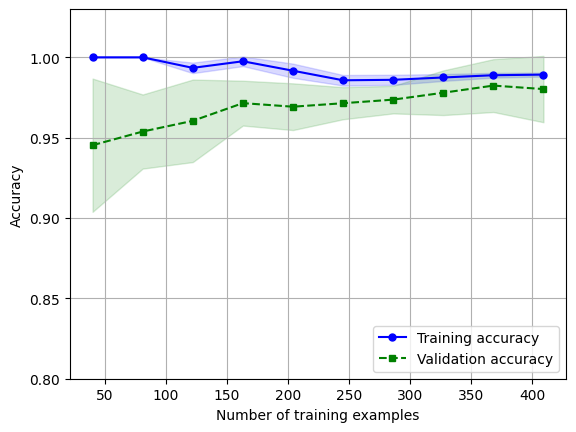

In [7]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

pipe_lr = make_pipeline(StandardScaler(),
                        LogisticRegression(l1_ratio = 0,
                                           max_iter=10000))

train_sizes, train_scores, test_scores = \
    learning_curve(estimator=pipe_lr,
                   X=X_train,
                   y=y_train,
                   train_sizes=np.linspace(0.1, 1.0, 10),
                   cv=10,
                   n_jobs=1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean, 
         color='blue', marker='o',
         markersize=5, label='Training accuracy')
plt.fill_between(train_sizes, 
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5, 
         label='Validation accuracy')
plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid()
plt.ylim([0.8, 1.03])
plt.show()

Note that we passed max_iter=10000 as an argument when instantiating the LogisticRegression object (which uses 1000 as a default) to avoid convergence issues for the smaller dataset sizes or extreme regularization parameter values. As we can see in the plot, our model performs quite well on both training and validation datasets if it has seen more than 250 examples during training. We can also see that the training accuracy increases for training datasets with fewer than 250, and the gap between validation and training accuracy widens, an indicator of an increasing degree of overfitting.

### Addressing Overfitting and Underfitting with Validation Curves

Validation curves are related to learning curves, but instead of plotting the training and test accuracies as functions of sample size, we vary the values of the model parameters, for example, the inverse of the regularization parameter, C, in logistic regression:

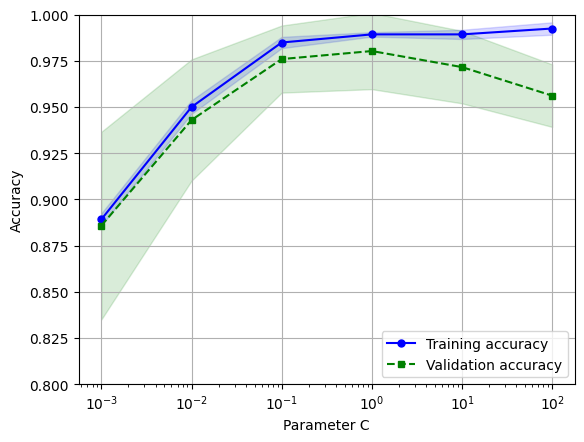

In [8]:
from sklearn.model_selection import validation_curve

param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(
    estimator=pipe_lr,
    X=X_train,
    y=y_train,
    param_name='logisticregression__C',
    param_range=param_range,
    cv=10)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')
plt.fill_between(param_range,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')
plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')
plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid()
plt.xscale('log')
plt.ylim([0.8, 1.0])
plt.show()

Similar to the learning_curve function, validation_curve uses stratified k-fold cross-validation by default to estimate the performance of the classifier. Inside the validation_curve function, we specified the parameter that we wanted to evaluate (C, written as 'logisticregression__C') to access the LogisticRegression object inside the scikit-learn pipeline for a specified value range that we set via the param_range parameter. Similar to the learning curve example in the previous section, we plotted the average training and cross-validation accuracies and the corresponding standard deviations. We can see that when we increase the regularization strength (small values of C), model is slightly underfitting the data.

### Fine-tuning Machine Learning Models via Grid Search

Let's use Grid Search to find the best hyperparameters for a linear SVM:

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svc = make_pipeline(StandardScaler(),
                         SVC(random_state=1))
param_range = [0.0001, 0.001, 0.01, 0.1, 
               1.0, 10.0, 100.0, 1000.0]
param_grid = [{'svc__C': param_range,
               'svc__kernel': ['linear']},
               {'svc__C': param_range,
                'svc__gamma': param_range,
                'svc__kernel': ['rbf']}]
gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring='accuracy',
                  cv=10,
                  refit=True,
                  n_jobs=-1)
gs = gs.fit(X_train, y_train)
print(gs.best_score_)
print(gs.best_params_)

0.9846859903381642
{'svc__C': 100.0, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}


For linear SVM, we only evaluated the inverse regularization parameter C, for the radial basis function (RBF) kernel SVM, we tuned both the C and the gamma parameters. GridSearchCV uses k-fold cross-validation for comparing models. We set the k to 10 and the scoring to accuracy to carry out 10-fold cross-validation and compute the average accuracy.

We can use the independent test dataset to estimate the performance of the best-selected model now:

In [10]:
clf = gs.best_estimator_
clf.fit(X_train, y_train)
print(f'Test accuracy: {clf.score(X_test, y_test):.3f}')

Test accuracy: 0.974


### Exploring Hyperparameter Configurations More Widely with Randomized Search

Let's look at how we can use randomized search for tuning an SVM now. RandomizedSearchCV is the scikit-learn implementation, main difference is that we can specify distributions as part of our parameter grid and specify the total number of hyperparameter configurations to be evaluated. 

In [11]:
import scipy.stats
param_range = scipy.stats.loguniform(0.0001, 1000.0)

We could have used a set of discrete values like we did with grid search, but randomized search's main power lies in the fact that we can replace these lists with distributions to sample from, such as loguniform distribution. We can see the behavior of the distribution by drawing 10 random samples as such:

In [12]:
np.random.seed(1)
param_range.rvs(10)

array([8.30145146e-02, 1.10222804e+01, 1.00184520e-04, 1.30715777e-02,
       1.06485687e-03, 4.42965766e-04, 2.01289666e-03, 2.62376594e-02,
       5.98924832e-02, 5.91176467e-01])

Now, let's see RandomizedSearchCV in action and tune an SVM as we did with GridSearchCV:

In [13]:
from sklearn.model_selection import RandomizedSearchCV
pipe_svc = make_pipeline(StandardScaler(),
                         SVC(random_state=1))
param_grid = [{'svc__C': param_range,
               'svc__kernel': ['linear']},
               {'svc__C': param_range,
                'svc__gamma': param_range,
                'svc__kernel': ['rbf']}]

rs = RandomizedSearchCV(estimator=pipe_svc,
                        param_distributions=param_grid,
                        scoring='accuracy',
                        refit=True,
                        n_iter=20,
                        cv=10,
                        random_state=1,
                        n_jobs=-1)

rs = rs.fit(X_train, y_train)
print(rs.best_score_)
print(rs.best_params_)

0.9780676328502416
{'svc__C': np.float64(0.05971247755848463), 'svc__kernel': 'linear'}


We can see that it is very similar to GridSearchCV, but you specify the number of iterations within the parameter range with the n_iter argument

### More Resource-Efficient Hyperparameter Search with Successive Halving

Let's now experiment with halving random search. We need to enable it first on scikit-learn since it is still experimental:

In [14]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

hs = HalvingRandomSearchCV(pipe_svc,
                           param_distributions=param_grid,
                           n_candidates='exhaust',
                           resource='n_samples',
                           factor=1.5,
                           random_state=1,
                           n_jobs=-1)

hs = hs.fit(X_train, y_train)
print(hs.best_score_)
print(hs.best_params_)

clf = hs.best_estimator_
print(f'Test accuracy: {clf.score(X_test, y_test):.3f}')

0.9617647058823529
{'svc__C': np.float64(4.934834261073333), 'svc__kernel': 'linear'}
Test accuracy: 0.982


The resource is set to 'n_samples', specifying that we consider the training set size as the resource we vary between the rounds. Via the factor parameter, we can determine how many candidates are eliminated in each round. Setting factor to 2 eliminates half of the candidates, while setting it to 1.5 means 66% of the candidates make it to the next round. Instead of choosing a fixed number of iterations, we set n_candidates to 'exhaust' which will sample the number of hyperparameter configurations such that the maximum number of resources (training examples) are used in last round.

### Algorithm Selection with Nested Cross-Validation

Let's now take a look at nested cross-validation with grid search, using 5 outer folds and 2 inner folds (5 $\times$ 2 cross-validation):

In [15]:
param_range = [0.0001, 0.001, 0.01, 
               0.1, 1.0, 10.0, 100.0, 1000.0]

param_grid = [{'svc__C': param_range,
               'svc__kernel': ['linear']},
               {'svc__C': param_range,
                'svc__gamma': param_range,
                'svc__kernel': ['rbf']}]

gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring='accuracy',
                  cv=2)

scores = cross_val_score(gs, X_train, y_train,
                         scoring='accuracy', cv=5)
print(f'CV accuracy: {np.mean(scores):.3f} ± {np.std(scores):.3f}')

CV accuracy: 0.974 ± 0.015


The returned average cross-validation accuracy gives us a good estimate of what to expect if we tune the hyperparameters of a model and use it on unseen data. We can use the nested cross-validation to compare an SVM model to a simple decision tree classifier:

In [16]:
from sklearn.tree import DecisionTreeClassifier

gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                  param_grid=[{'max_depth': [1, 2, 3, 4, 5, 6, 7, None]}],
                  scoring='accuracy',
                  cv=2)

scores = cross_val_score(gs, X_train, y_train,
                         scoring='accuracy', cv=5)
print(f'CV accuracy: {np.mean(scores):.3f} ± {np.std(scores):.3f}')

CV accuracy: 0.934 ± 0.016


As we can see, the performance of the SVM model (97.4 percent) is notably better than the performance of the decision tree (93.4 percent), and thus, we'd expect that it might be the better choice to classify new data that comes from the same population as this particular dataset. 

### Looking at Different Performance Evaluation Metrics

We can use the conveniently provided confusion matrix from scikit-learn to calculate different performance metrics:

In [17]:
from sklearn.metrics import confusion_matrix
pipe_svc.fit(X_train, y_train)
y_pred = pipe_svc.predict(X_test)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[71  1]
 [ 2 40]]


Instead of printing the contents, we can also make an illustration as such:

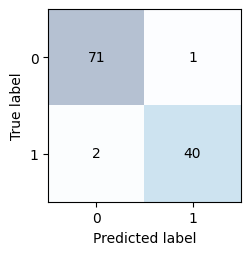

In [18]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j],
                va='center', ha='center')
        
ax.xaxis.set_ticks_position('bottom')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

The confusion matrix plot, with the added labels, makes the results a little bit easier to interpret. Assuming that class 1 (malignant) is the positive class in the example, our model correctly classified 71 of the examples that belong to class 0 (TN) and 40 examples that belong to class 1 (TP), respectively. However, our model also incorrectly misclassified two examples from class 1 as class 0 (FN) and it predicted that one example is malignant although it is a benign tumor (FP).

### Optimizing the Precision and Recall of a Classification Model

The scoring metrics are all implemented in scikit-learn and can be imported as follows:

In [20]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import matthews_corrcoef

pre_val = precision_score(y_true=y_test, y_pred=y_pred)
print(f'Precision: {pre_val:.3f}')

rec_val = recall_score(y_true=y_test, y_pred=y_pred)
print(f'Recall: {rec_val:.3f}')


f1_val = f1_score(y_true=y_test, y_pred=y_pred)
print(f'F1 Score: {f1_val:.3f}')

mcc_val = matthews_corrcoef(y_true=y_test, y_pred=y_pred)
print(f'MCC: {mcc_val:.3f}')


Precision: 0.976
Recall: 0.952
F1 Score: 0.964
MCC: 0.943


Furthermore, we can use a different scoring metric than accuracy in the GridSearchCV via the scoring parameter. Remember that the positive class in scikit-learn is the class that is labeled as class 1. If we want to specify a different positive label, we can construct our own scorer via the make_scorer function, which we can then directly provide as an argument to the scoring parameter in GridSearchCV:

In [21]:
from sklearn.metrics import make_scorer

c_gamma_range = [0.01, 0.1, 1.0, 10.0]
param_grid = [{'svc__C': c_gamma_range,
               'svc__kernel': ['linear']},
               {'svc__C': c_gamma_range,
                'svc__gamma': c_gamma_range,
                'svc__kernel': ['rbf']}]
scorer = make_scorer(f1_score, pos_label=0)
gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring=scorer,
                  cv=10)
gs = gs.fit(X_train, y_train)

print(gs.best_score_)
print(gs.best_params_)

0.9861994953378878
{'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


### Plotting a Receiver Operating Characteristic

Let's plot a ROC curve of a classifier that only uses two features from the Breast Cancer Wisconsin dataset to predict whether a tumor is benign or malignant. Although we are going to use the same logistic regression pipeline that we defined previously, we are only using two features this time. This is to make the classification task more challenging for the classifier, by withholding useful information contained in other features, so that the resulting ROC curve becomes visually more interesting. For similar reasons, we are also reducing the number of folds in the StratifiedKFold validator to three:

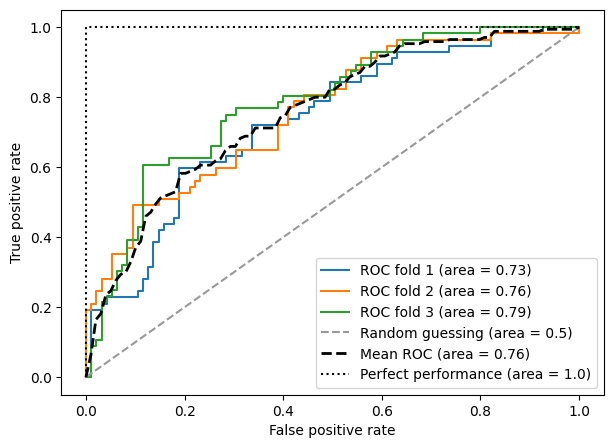

In [22]:
from sklearn.metrics import roc_curve, auc
from numpy import interp

pipe_lr = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
    LogisticRegression(l1_ratio=0, random_state=1,
                       solver='lbfgs', C=100.0)
)
X_train2 = X_train[:, [4, 14]]
cv = list(StratifiedKFold(n_splits=3).split(X_train, y_train))
fig = plt.figure(figsize=(7, 5))
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train, test) in enumerate(cv):
    probas = pipe_lr.fit(X_train2[train], y_train[train]
    ).predict_proba(X_train2[test])
    fpr, tpr, thresholds = roc_curve(y_train[test],
                                     probas[:, 1],
                                     pos_label=1)
    mean_tpr += interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr,
             tpr,
             label=f'ROC fold {i + 1} (area = {roc_auc:.2f})')

plt.plot([0, 1],
         [0, 1],
         linestyle='--',
         color=(0.6, 0.6, 0.6),
         label='Random guessing (area = 0.5)')

mean_tpr /= len(cv)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, 'k--',
         label=f'Mean ROC (area = {mean_auc:.2f})',
         lw=2)
plt.plot([0, 0, 1],
         [0, 1, 1], 
         linestyle=':',
         color='black',
         label='Perfect performance (area = 1.0)')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc='lower right')
plt.show()

Note that if we are just interested in the ROC AUC score, we could also import the roc_auc_score function from sklearn.metrics submodule. 

### Dealing with Class Imbalance

Imagine that the Breast Cancer Wisconsin dataset that we have been working with consisted of 90 percent healthy patients. In this case, we could achieve 90 percent accuracy on the test set by just predicting the majority class (benign tumor) for all examples, without the help of a supervised machine learning algorithm. Thus, training a model on such a dataset that achieves approximately 90 percent test accuracy would mean our model hasn't learned anything useful form the features provided in the dataset.

Let's first create an imbalanced dataset from our dataset before discussing some of the techniques that could help with imbalanced datasets:

In [23]:
X_imb = np.vstack((X[y == 0], X[y == 1][:40]))
y_imb = np.hstack((y[y == 0], y[y == 1][:40]))

In the previous code snippet, we took all the 357 benign tumor examples (class 0) and stacked them with the first 40 malignant examples to create a stark class imbalance. If we were to compute the accuracy of a model that always predicts the majority class (benign, class 0), we would achieve a prediction accuracy of approximately 90 percent:

In [27]:
y_pred = np.zeros(y_imb.shape[0])
print(np.mean(y_pred == y_imb) * 100)

89.92443324937027


The scikit-learn library implements a simple resample function that can help with the upsampling of the minority class by drawing new samples from the dataset with replacement. The following code will take the minority class from our imbalanced Breast Cancer Wisconsin dataset (here, class 1) and repeatedly draw new samples from it until it contains the same number of examples as class label 0:

In [28]:
from sklearn.utils import resample
print('Number of class 1 examples before:', X_imb[y_imb == 1].shape[0])
X_upsampled, y_upsampled = resample(X_imb[y_imb == 1],
                                    y_imb[y_imb == 1],
                                    replace=True,
                                    n_samples=X_imb[y_imb == 0].shape[0],
                                    random_state=123)
print('Number of class 1 examples after:', X_upsampled.shape[0])


Number of class 1 examples before: 40
Number of class 1 examples after: 357


After resampling, we can then stack the original class 0 samples with the upsampled class 1 subset to obtain a balanced dataset as follows:

In [29]:
X_bal = np.vstack((X[y==0], X_upsampled))
y_bal = np.hstack((y[y==0], y_upsampled))

Consequently, a majority vote prediction rule would only achieve 50 percent accuracy:

In [31]:
y_pred = np.zeros(y_bal.shape[0])
print(np.mean(y_pred == y_bal) * 100)

50.0


Similarly, we could downsample the majority class by removing training examples from the dataset. To perform downsampling using the resample function, we could simply swap the class 1 label with class 0 in the previous code example.